In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy import stats
import joblib

In [35]:
df = pd.read_excel('Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.6+ MB


# Preprocessing Data

In [36]:
# Cek dan Hapus nilai yang kosong (Jika Ada)
null = df.isnull().sum()
print(f"Data yang kosong:\n{null}")

total_null = df.isnull().sum().sum()

if total_null > 0:
    df.dropna(inplace=True)
    null_after = df.isnull().sum()
    print(f"\nData setelah nilai yang kosong dihapus:\n{null_after}")
else:
    print("Tidak ada data yang hilang")

Data yang kosong:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Data setelah nilai yang kosong dihapus:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [37]:
# Cek dan Hapus nilai yang duplikat (Jika Ada)
duplicate = df.duplicated().sum()
print(f"Kolom duplikat: {duplicate}\n")
if duplicate > 0:
    print("Terdapat Kolom yang duplikat")
    df.drop_duplicates(inplace=True)
    print(f"Kolom duplikat: {df.duplicated().sum()}")
else:
    print("Tidak ada kolom yang duplikat")


Kolom duplikat: 5225

Terdapat Kolom yang duplikat
Kolom duplikat: 0


# Feature Engineering

In [38]:
# Ubah CustomerID menjadi Integer
df['CustomerID'] = df['CustomerID'].astype(int)

# Ubah kolom InvoiceNo menjadi string
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

# Hapus transaksi yang dibatalkan
df = df[~df['InvoiceNo'].str.startswith('C')]

# Hapus data Quantity dan UnitPrice yang tidak valid
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [39]:
# Membuat total harga per baris transaksi
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Tanggal acuan untuk menghitung Recency
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Membuat data per customer
customer_df = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum',
    'Quantity': 'sum',
    'StockCode': 'nunique'
}).reset_index()

# Rename kolom
customer_df.columns = [
    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary',
    'TotalQuantity',
    'UniqueProduct'
]

# Membuat feature tambahan
customer_df['AverageOrderValue'] = customer_df['Monetary'] / customer_df['Frequency']


Pada tahap feature engineering, dataset yang awalnya berbentuk data transaksi diubah menjadi data per pelanggan. Hal ini dilakukan karena tujuan dari project ini adalah melakukan segmentasi pelanggan menggunakan clustering. Setiap baris pada data hasil feature engineering merepresentasikan satu pelanggan berdasarkan `CustomerID`.

- <b>1. CustomerID : </b>
`CustomerID` merupakan identitas unik untuk setiap pelanggan. Kolom ini digunakan sebagai dasar pengelompokan data transaksi agar seluruh transaksi milik pelanggan yang sama dapat digabungkan menjadi satu baris data pelanggan.
- <b>2. Recency : </b> 
`Recency` menunjukkan jumlah hari sejak pelanggan terakhir melakukan transaksi. Nilai ini dihitung dari selisih antara tanggal acuan dengan tanggal transaksi terakhir pelanggan. Semakin kecil nilai `Recency`, maka semakin baru pelanggan tersebut melakukan pembelian. Sebaliknya, semakin besar nilai `Recency`, maka semakin lama pelanggan tersebut tidak melakukan pembelian.
- <b>3. Frequency : </b>  
`Frequency` menunjukkan jumlah transaksi unik yang dilakukan oleh setiap pelanggan. Fitur ini dihitung berdasarkan jumlah `InvoiceNo` yang berbeda pada masing-masing `CustomerID`. Semakin tinggi nilai `Frequency`, maka pelanggan tersebut semakin sering melakukan transaksi.
- <b>4. Monetary : </b>  
`Monetary` menunjukkan total nilai belanja yang dikeluarkan oleh setiap pelanggan. Fitur ini dihitung dari penjumlahan seluruh nilai `TotalPrice` milik pelanggan. Semakin tinggi nilai `Monetary`, maka semakin besar kontribusi pelanggan tersebut terhadap total penjualan.
- <b>5. TotalQuantity : </b>  
`TotalQuantity` menunjukkan total jumlah barang yang dibeli oleh setiap pelanggan. Fitur ini dihitung dari penjumlahan seluruh nilai `Quantity` pada transaksi pelanggan. Nilai ini dapat digunakan untuk melihat seberapa banyak produk yang dibeli oleh pelanggan secara keseluruhan.
- <b>6. UniqueProduct : </b>  
`UniqueProduct` menunjukkan jumlah jenis produk berbeda yang pernah dibeli oleh setiap pelanggan. Fitur ini dihitung berdasarkan jumlah `StockCode` unik pada masing-masing pelanggan. Semakin tinggi nilai `UniqueProduct`, maka semakin beragam produk yang dibeli oleh pelanggan tersebut.
- <b>7. AverageOrderValue : </b> 
`AverageOrderValue` menunjukkan rata-rata nilai belanja pelanggan dalam setiap transaksi. Fitur ini dihitung dengan membagi nilai `Monetary` dengan `Frequency`. Fitur ini berguna untuk mengetahui rata-rata pengeluaran pelanggan setiap kali melakukan pembelian.
- <b>8. TotalPrice : </b>
`TotalPrice` merupakan fitur tambahan pada data transaksi yang dihitung dari perkalian antara `Quantity` dan `UnitPrice`. Fitur ini digunakan untuk mengetahui total harga pada setiap baris transaksi sebelum data dikelompokkan berdasarkan pelanggan.

Rumus:
TotalPrice = Quantity × UnitPrice

# EDA Pada Data Kolom Baru

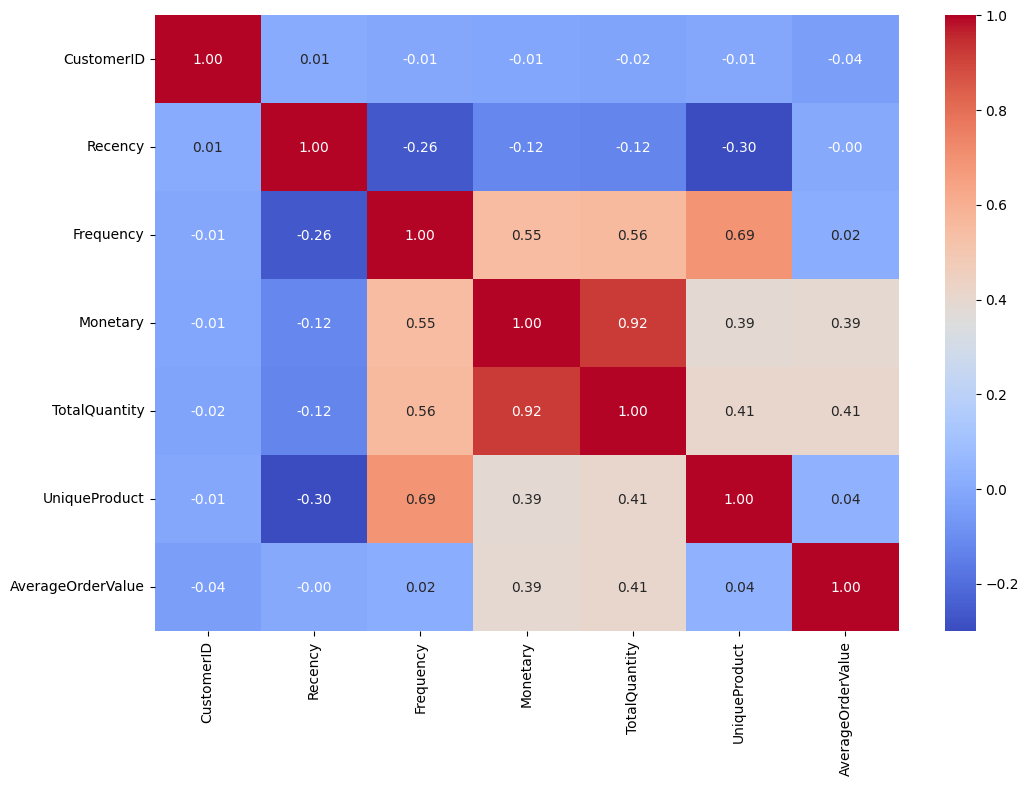

In [ ]:
# Heatmap untuk lihat korelasi antar fitur
corr = customer_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

Dari heatmap diatas diketahui bahwa terdapat beberapa kolom yang memiliki korelasi yang sangat tinggi antar kolomnya, yang nantinya akan menjadi pertimbangan untuk tidak digunakan dalam proses clustering.

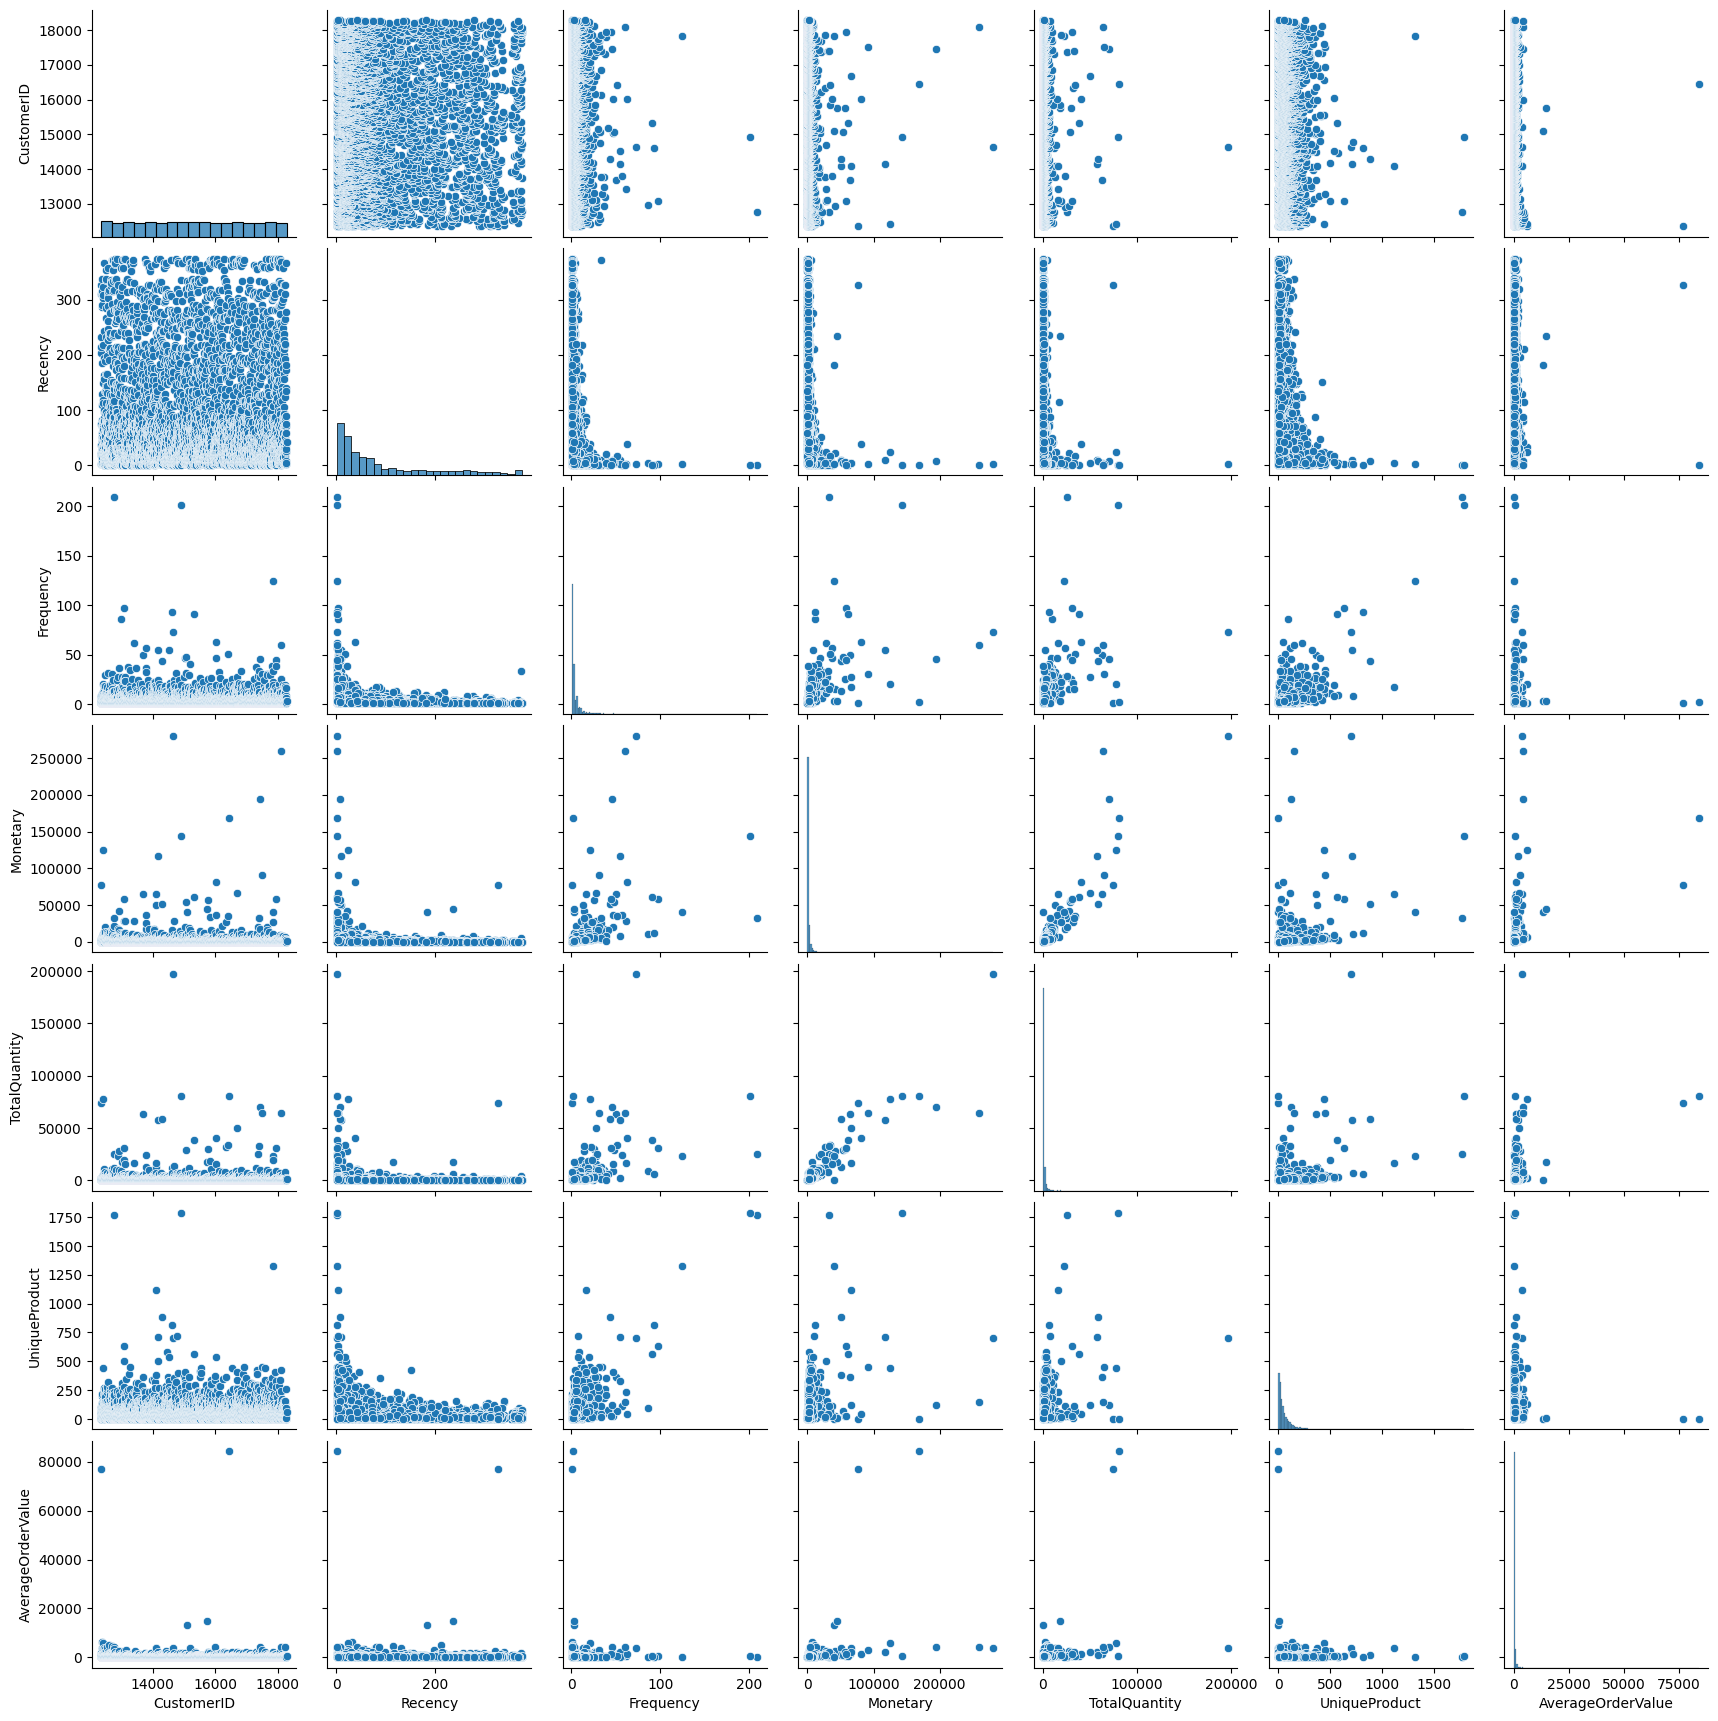

In [ ]:
# Cek korelasi antar kolom dengan scatter plot
sns.pairplot(customer_df, kind='scatter')

In [40]:
# Pengecekan Skewness pada Fitur
features = [
    'Recency',
    'Frequency',
    'Monetary',
    'TotalQuantity',
    'UniqueProduct',
    'AverageOrderValue'
]
customer_df[features].skew().sort_values(ascending=False)

AverageOrderValue    41.692422
TotalQuantity        20.383991
Monetary             19.339368
Frequency            12.067031
UniqueProduct         6.919445
Recency               1.246048
dtype: float64

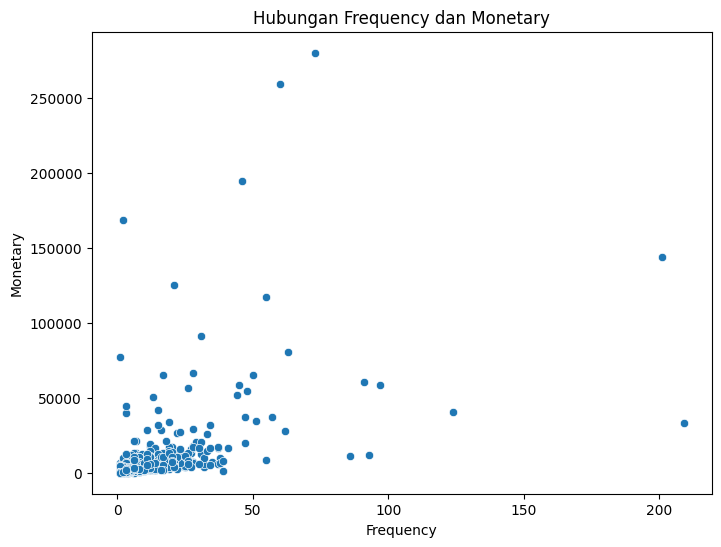

In [15]:
# Melihat Hubungan antara Kolom Frecuency dan Monetary
plt.figure(figsize=(8, 6))
sns.scatterplot(data=customer_df, x='Frequency', y='Monetary')
plt.title('Hubungan Frequency dan Monetary')
plt.show()

# Preprocessing Data

In [41]:
# Mengatasi nilai skew yang tinggi dan mendeklarasikan variabel dengan fitur yang akan digunakan.
features_rfm = ['Recency', 'Frequency', 'Monetary']

customer_rfm = customer_df.copy()
customer_rfm[features_rfm] = np.log1p(customer_rfm[features_rfm])

print("Skewness sebelum log transform:")
print(customer_df[features_rfm].skew().sort_values(ascending=False))
print("\nSkewness setelah log transform:")
print(customer_rfm[features_rfm].skew().sort_values(ascending=False))

Skewness sebelum log transform:
Monetary     19.339368
Frequency    12.067031
Recency       1.246048
dtype: float64

Skewness setelah log transform:
Frequency    1.208652
Monetary     0.396599
Recency     -0.379169
dtype: float64


Jumlah outlier per fitur:
86


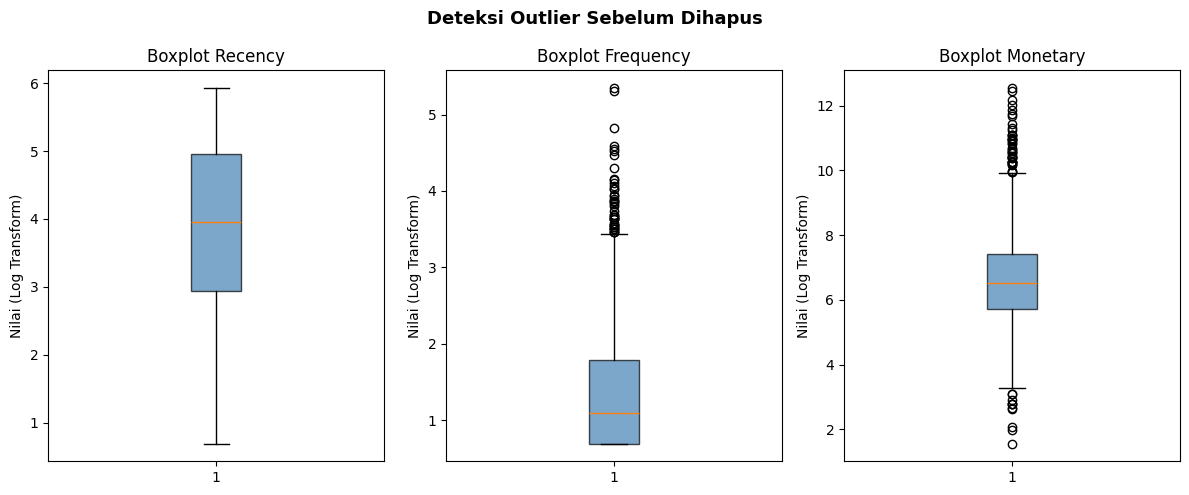


Data sebelum : 4338 pelanggan
Data sesudah : 4271 pelanggan
Outlier dibuang: 67 pelanggan


In [42]:
# Cek dan Hapus outlier
z_scores = np.abs(stats.zscore(customer_rfm[features_rfm]))

# Jumlah outlier per fitur
print("Jumlah outlier per fitur:")
print((z_scores > 3).sum())

# Visualisasi boxplot sebelum hapus outlier
plt.figure(figsize=(12, 5))
for i, col in enumerate(features_rfm, 1):
    plt.subplot(1, 3, i)
    plt.boxplot(customer_rfm[col], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
    plt.title(f'Boxplot {col}')
    plt.ylabel('Nilai (Log Transform)')
plt.suptitle('Deteksi Outlier Sebelum Dihapus', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Hapus outlier
mask = (z_scores < 3).all(axis=1)
customer_clean = customer_rfm[mask].copy()
print(f"\nData sebelum : {len(customer_rfm)} pelanggan")
print(f"Data sesudah : {len(customer_clean)} pelanggan")
print(f"Outlier dibuang: {len(customer_rfm) - len(customer_clean)} pelanggan")

In [48]:
# Scaling
scaler = StandardScaler()
X_scaled_rfm = scaler.fit_transform(customer_clean[features_rfm])

print("Scaling selesai, shape:", X_scaled_rfm.shape)

Scaling selesai, shape: (4271, 3)


# Modeling

K=2 → Silhouette: 0.4339
K=3 → Silhouette: 0.3263
K=4 → Silhouette: 0.3356
K=5 → Silhouette: 0.3151
K=6 → Silhouette: 0.3114
K=7 → Silhouette: 0.3064
K=8 → Silhouette: 0.3006
K=9 → Silhouette: 0.2814
K=10 → Silhouette: 0.2786

K optimal: 2 (Silhouette: 0.4339)


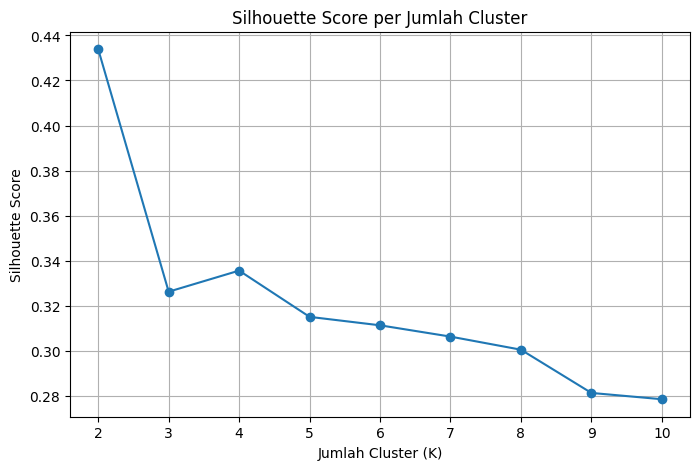

In [49]:
# Cari K optimal
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled_rfm)
    score = silhouette_score(X_scaled_rfm, labels)
    silhouette_scores.append(score)
    print(f"K={k} → Silhouette: {score:.4f}")

best_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nK optimal: {best_k} (Silhouette: {max(silhouette_scores):.4f})")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score per Jumlah Cluster')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [56]:
# Membuat model dengan KMeans
model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
customer_clean['Cluster'] = model.fit_predict(X_scaled_rfm)

print(f"Model selesai dengan K={best_k}")
print(f"\nDistribusi cluster:")
print(customer_clean['Cluster'].value_counts().sort_index())
df = customer_clean

Model selesai dengan K=2

Distribusi cluster:
Cluster
0    2586
1    1685
Name: count, dtype: int64


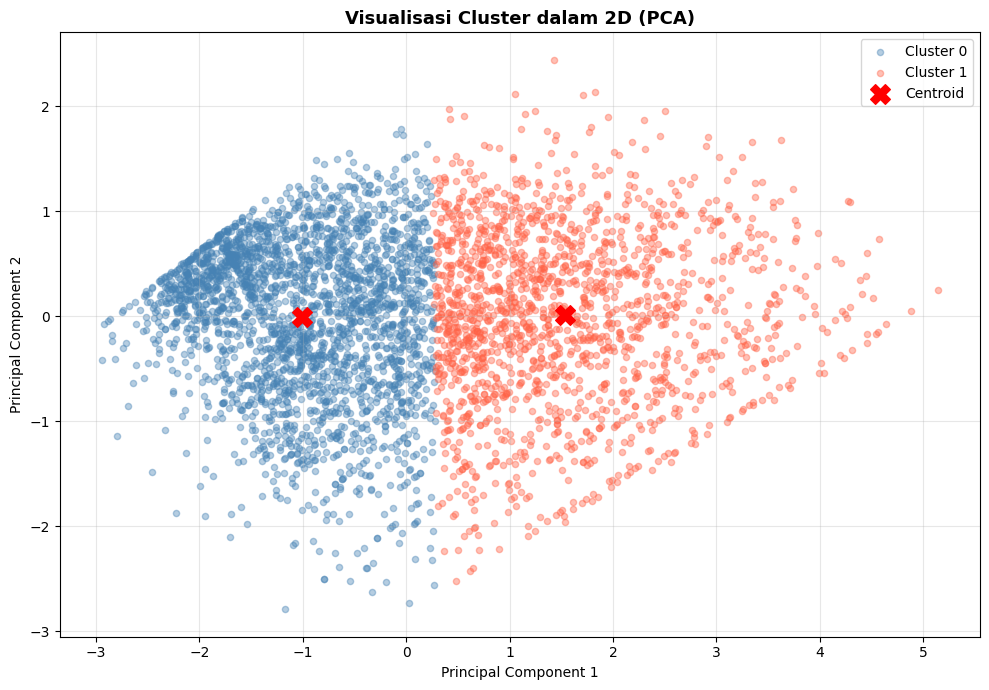

Variansi PC1: 74.1%
Variansi PC2: 19.5%
Total       : 93.6%


In [59]:
from sklearn.decomposition import PCA

#Reduksi dimensi ke 2D dengan PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled_rfm)

# Buat dataframe PCA
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['Cluster'] = customer_clean['Cluster'].values

# Hitung posisi centroid di ruang PCA
centroids_pca = pca.transform(model.cluster_centers_)

# Plot
colors = {0: 'steelblue', 1: 'tomato'}

plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df['Cluster'].unique()):
    mask = pca_df['Cluster'] == cluster
    plt.scatter(
        pca_df[mask]['PC1'],
        pca_df[mask]['PC2'],
        c=colors[cluster],
        label=f'Cluster {int(cluster)}',
        alpha=0.4, s=20
    )

# Plot centroid
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c='red', marker='X', s=200,
    zorder=5, label='Centroid'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Visualisasi Cluster dalam 2D (PCA)', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cek berapa % variansi yang dijelaskan PC1 & PC2
print(f"Variansi PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variansi PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total       : {sum(pca.explained_variance_ratio_)*100:.1f}%")

In [57]:
# Evaluasi Model
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

labels = df['Cluster']

silhouette    = silhouette_score(X_scaled_rfm, labels)
davies_bouldin    = davies_bouldin_score(X_scaled_rfm, labels)
calinski_harabasz = calinski_harabasz_score(X_scaled_rfm, labels)
inertia           = model.inertia_

print(f"Silhouette Score       : {silhouette:.4f}")
print(f"Davies-Bouldin Index   : {davies_bouldin:.4f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz:.4f}")
print(f"Inertia                : {inertia:.4f}")

Silhouette Score       : 0.4339
Davies-Bouldin Index   : 0.8883
Calinski-Harabasz Score: 4516.5182
Inertia                : 6226.0069


In [ ]:
# Ekspor model
joblib.dump(model, "Clustering_KMeans.h5")

['Clustering_KMeans.h5']

In [ ]:
# Ubah dataset hasil clustering ke dalam file csv
df.to_csv("data_clustering.csv", index=False)